In [4]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.1 MB/s eta 0:00:00


In [12]:
import geopandas as gpd
import osmnx as ox
import pandas as pd
import numpy as np
from shapely.geometry import box, Polygon

CRS_PROJ = "EPSG:32644"
PLACE_NAME = "Novosibirsk, Russia"

TAGS = {
    "science": {
        "amenity": ["research_institute", "university"],
        "office": ["research", "educational_institution"],
        "landuse": ["education"]
    },
    "industry": {
        "landuse": ["industrial", "brownfield"],
        "man_made": ["works", "wastewater_plant"],
        "power": ["plant", "substation"]
    },
    "demography": {
        "landuse": ["residential"],
        "building": ["apartments", "residential", "house", "dormitory"]
    }
}

def create_grid(gdf_boundary, resolution=1000):
    """
    Генерирует сетку квадратов указанного разрешения (в метрах)
    внутри границ полигона.
    """
    gdf_boundary = gdf_boundary.to_crs(CRS_PROJ)
    minx, miny, maxx, maxy = gdf_boundary.total_bounds

    cols = list(np.arange(minx, maxx, resolution))
    rows = list(np.arange(miny, maxy, resolution))

    polygons = []
    for x in cols:
        for y in rows:
            poly = box(x, y, x + resolution, y + resolution)
            if poly.intersects(gdf_boundary.unary_union):
                polygons.append(poly)

    grid = gpd.GeoDataFrame({'geometry': polygons}, crs=CRS_PROJ)
    grid['cell_id'] = range(len(grid))
    return grid

def fetch_layer_data(place, tags):
    """
    Скачивает геометрии OSM по тегам и преобразует в метрическую проекцию.
    """
    try:
        print(f"Загрузка слоя: {list(tags.keys())} ...")
        gdf = ox.features_from_place(place, tags=tags)

        gdf = gdf[gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

        gdf = gdf.to_crs(CRS_PROJ)[['geometry']]
        return gdf
    except Exception as e:
        print(f"Данные не найдены или ошибка: {e}")
        return gpd.GeoDataFrame(crs=CRS_PROJ, geometry=[])

def calculate_zonal_stats(grid, data_gdf, column_name):
    """
    Рассчитывает площадь перекрытия объектов с каждой ячейкой сетки.
    """
    if data_gdf.empty:
        grid[column_name] = 0.0
        return grid

    intersection = gpd.overlay(grid, data_gdf, how='intersection')

    intersection['area_chunk'] = intersection.geometry.area

    stats = intersection.groupby('cell_id')['area_chunk'].sum().reset_index()
    stats.rename(columns={'area_chunk': column_name}, inplace=True)

    grid = grid.merge(stats, on='cell_id', how='left')
    grid[column_name] = grid[column_name].fillna(0)

    return grid

print("Шаг 1: Получение границ региона")
region_boundary = ox.geocode_to_gdf(PLACE_NAME)

print(f"Шаг 2: Генерация сетки 1x1 км для {PLACE_NAME}")
grid = create_grid(region_boundary)
print(f"   Всего ячеек: {len(grid)}")

print("Шаг 3: Скачивание данных OSM и расчет площадей")

layers = {
    'raw_science_area': TAGS['science'],
    'raw_industry_area': TAGS['industry'],
    'raw_demo_area': TAGS['demography']
}

for col_name, tag_set in layers.items():
    gdf_features = fetch_layer_data(PLACE_NAME, tag_set)
    grid = calculate_zonal_stats(grid, gdf_features, col_name)

print("Шаг 4: Расчет финальных коэффициентов модели (W)")

cell_area = 1000000

grid['w_science'] = np.where(
    grid['raw_science_area'] > 0,
    1 + np.log1p(grid['raw_science_area']), # Логарифмический буст
    0
)

grid['w_industry'] = grid['raw_industry_area'] / cell_area

grid['w_demography'] = grid['raw_demo_area'] / cell_area

threshold = 0.001
grid.loc[grid['w_industry'] < threshold, 'w_industry'] = 0
grid.loc[grid['w_demography'] < threshold, 'w_demography'] = 0

print("\n Пример первых 5 ячеек с весами:")
print(grid[['cell_id', 'w_science', 'w_industry', 'w_demography']].head())

Шаг 1: Получение границ региона
Шаг 2: Генерация сетки 1x1 км для Novosibirsk, Russia


/tmp/ipykernel_44786/3339538928.py:42: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  if poly.intersects(gdf_boundary.unary_union):


   Всего ячеек: 598
Шаг 3: Скачивание данных OSM и расчет площадей
Загрузка слоя: ['amenity', 'office', 'landuse'] ...
Загрузка слоя: ['landuse', 'man_made', 'power'] ...
Загрузка слоя: ['landuse', 'building'] ...
Шаг 4: Расчет финальных коэффициентов модели (W)

 Пример первых 5 ячеек с весами:
   cell_id  w_science  w_industry  w_demography
0        0        0.0         0.0      0.372957
1        1        0.0         0.0      0.023714
2        2        0.0         0.0      0.000000
3        3        0.0         0.0      0.000000
4        4        0.0         0.0      0.000000


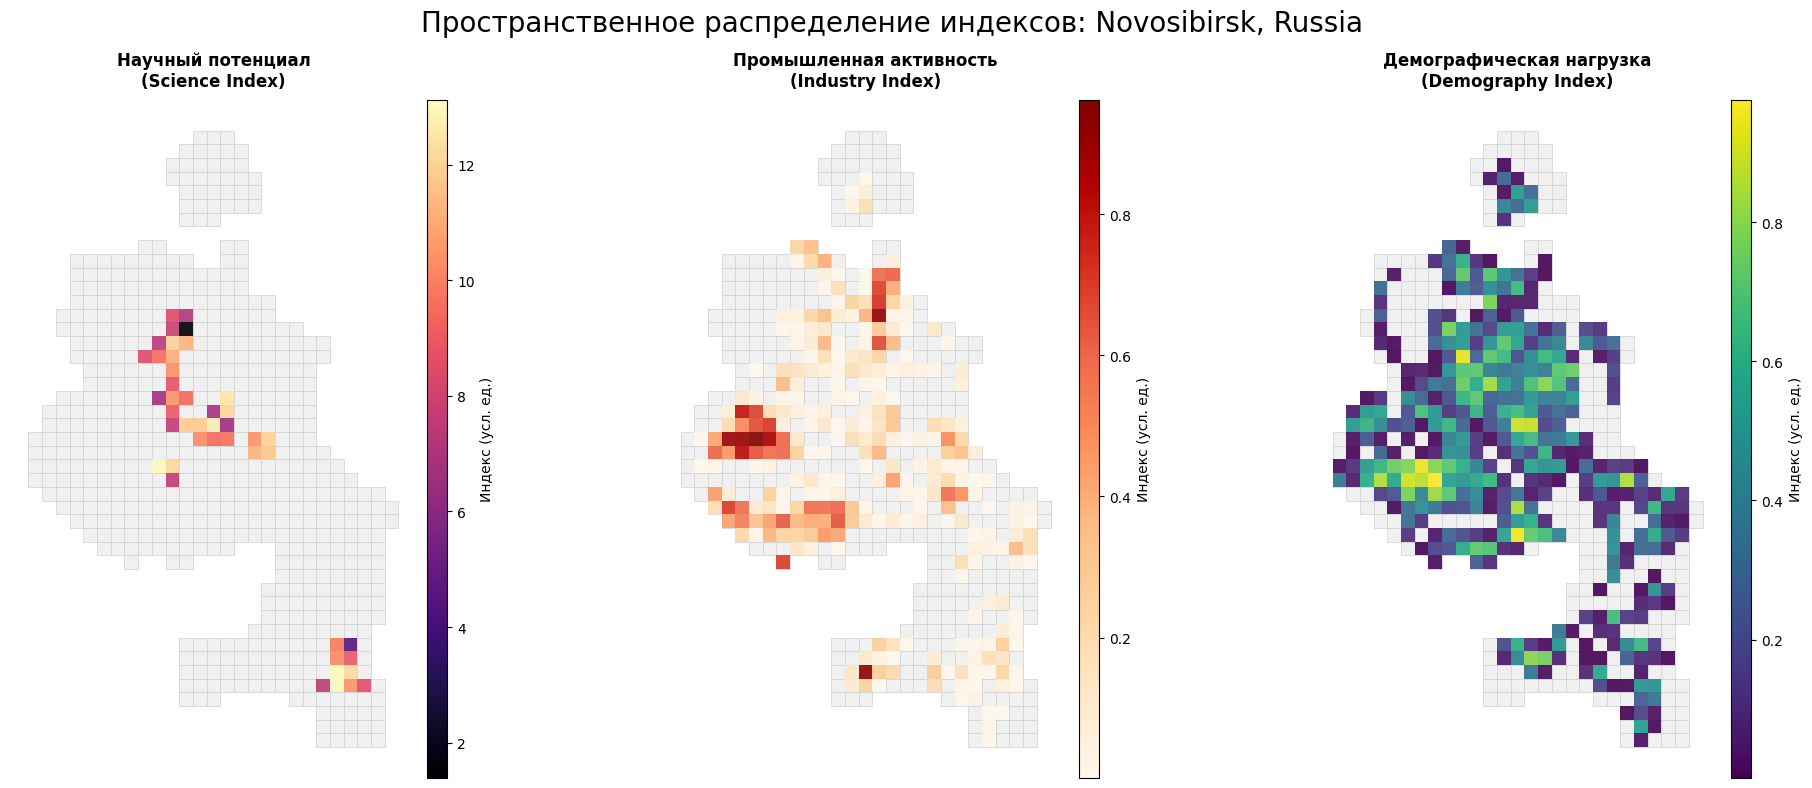

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
plt.suptitle(f'Пространственное распределение индексов: {PLACE_NAME}', fontsize=20)

maps_config = [
    ('w_science', 'Научный потенциал\n(Science Index)', 'magma'),
    ('w_industry', 'Промышленная активность\n(Industry Index)', 'OrRd'),
    ('w_demography', 'Демографическая нагрузка\n(Demography Index)', 'viridis')
]

for ax, (col, title, cmap_name) in zip(axes, maps_config):
    grid.plot(ax=ax, color='#f0f0f0', edgecolor='#d0d0d0', linewidth=0.5)

    active_data = grid[grid[col] > 0]

    if not active_data.empty:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)

        active_data.plot(
            column=col,
            ax=ax,
            legend=True,
            cax=cax,
            cmap=cmap_name,
            edgecolor='none',
            alpha=0.9,
            legend_kwds={'label': 'Индекс (усл. ед.)'}
        )
    else:
        ax.text(0.5, 0.5, "НЕТ ДАННЫХ", ha='center', transform=ax.transAxes, color='red')

    ax.set_title(title, fontsize=12, pad=10, fontweight='bold')
    ax.set_axis_off()

plt.tight_layout()
plt.show()
